# EMV vs MLE — Wang & Zhou (2019) — Section 5.1 (Stationnaire)

## 1. Imports

In [39]:
import math
import numpy as np
import matplotlib.pyplot as plt
import time
import random

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 2. Paramètres et simulateur de marché

In [40]:
# Paramètres fixes (Section 5.1, p.27)
T = 1.0
dt = 1.0 / 252
n_steps = int(round(T / dt))   # 252
x0 = 1.0
z = 1.4
r_rate = 0.02

# Gardes-fous numériques minimaux
# - phi2 > 0 est structurel dans le papier
# - le clip sur log-variance évite les overflow/underflow exponentiels
PHI2_CLIP = (1e-12, 10.0)
LOG_VAR_CLIP = (-50.0, 50.0)

print(f"n_steps={n_steps}, dt={dt:.6f}")

n_steps=252, dt=0.003968


`sharpe_ratio` calcule $\rho = (\mu-r)/\sigma$. 

`compute_w_star` calcule la valeur fermée de $w^\star$. C’est le multiplicateur de Lagrange qui permet d’imposer la contrainte $E[X_T]=z$.

`simulate_gbm_prices` simule une trajectoire de prix de l’actif risqué sous un mouvement brownien géométrique, avec $\mu$ et $\sigma$ constants.

`discounted_wealth_step` met à jour la richesse actualisée entre $t$ et $t+\Delta t$. On prend la position risquée $u_t$, puis on lui applique le rendement actualisé réalisé sur ce pas de temps.

In [41]:
def sharpe_ratio(mu, r, sigma):
    # Ratio de Sharpe du modèle
    return (mu - r) / sigma

def compute_w_star(rho, T=1.0, x0=1.0, z=1.4, tol=1e-14):
    # Multiplicateur de Lagrange en forme fermée
    a = rho**2 * T
    denom = math.expm1(a)

    # Cas dégénéré : rho ≈ 0
    if abs(denom) < tol:
        if abs(z - x0) < tol:
            return np.nan
        raise ValueError("rho ≈ 0 et z != x0 : cible non atteignable.")

    e = math.exp(a)
    return (z * e - x0) / denom

def simulate_gbm_prices(mu, sigma, n_prices, dt, S0, rng):
    # Simulation d'un GBM sur la grille de temps
    eps = rng.normal(0.0, 1.0, size=n_prices - 1)
    log_ret = (mu - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * eps

    S = np.empty(n_prices, dtype=float)
    S[0] = S0
    S[1:] = S0 * np.exp(np.cumsum(log_ret))
    return S

def discounted_wealth_step(x_t, u_t, s_t, s_tp1, r, dt):
    discounted_return = math.exp(-r * dt) * (s_tp1 / s_t) - 1.0
    return x_t + u_t * discounted_return

def wealth_step_direct(x_t, u_t, mu, sigma, r, dt, rng):
    rho = (mu - r) / sigma
    eps = rng.normal(0.0, 1.0)
    return x_t + sigma * u_t * (rho * dt + math.sqrt(dt) * eps)

## 3. EMV : fonctions de base

`V_theta_fn` définit la forme paramétrique de la fonction de valeur $V^\theta(t,x)$.

`emv_td_error` calcule l’erreur de Bellman continue utilisée dans l’étape de policy evaluation.

`grad_theta_fn` calcule les gradients par rapport à $\theta_1$ et $\theta_2$.

`grad_phi_fn` calcule les gradients par rapport à $\phi_1$ et $\phi_2$.

`emv_policy_mean_var` reconstruit la moyenne et la variance de la politique gaussienne à partir de $(\phi_1,\phi_2)$.

In [42]:
def V_theta_fn(theta0, theta1, theta2, theta3, w, T, x, t):
    # Eq. (44) : fonction de valeur paramétrique
    x_arr = np.asarray(x, dtype=float)
    t_arr = np.asarray(t, dtype=float)
    xd = x_arr - w
    return (xd**2) * np.exp(-theta3 * (T - t_arr)) + theta2 * (t_arr**2) + theta1 * t_arr + theta0

def emv_td_error(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                 vec_xi, vec_xi1, vec_ti, vec_ti1):
    # Eq. (42) : erreur de Bellman en temps continu
    vdot = (
        V_theta_fn(theta0, theta1, theta2, theta3, w, T, vec_xi1, vec_ti1)
        - V_theta_fn(theta0, theta1, theta2, theta3, w, T, vec_xi, vec_ti)
    ) / dt
    return vdot - lam * (phi1 + phi2 * (T - vec_ti))

def grad_theta_fn(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                  vec_xi, vec_xi1, vec_ti, vec_ti1):
    # Eq. (47) et (48) : gradients en theta1 et theta2
    td = emv_td_error(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                      vec_xi, vec_xi1, vec_ti, vec_ti1)
    g1 = float(np.sum(td * dt))
    g2 = float(np.sum(td * (vec_ti1**2 - vec_ti**2)))
    return g1, g2

def grad_phi_fn(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                vec_xi, vec_xi1, vec_ti, vec_ti1):
    # Eq. (49) et (50) : gradients en phi1 et phi2
    td = emv_td_error(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                      vec_xi, vec_xi1, vec_ti, vec_ti1)

    x1 = vec_xi1 - w
    x0 = vec_xi - w

    f1 = 2 * (x1**2) * np.exp(-2 * phi2 * (T - vec_ti1)) * (T - vec_ti1)
    f2 = 2 * (x0**2) * np.exp(-2 * phi2 * (T - vec_ti)) * (T - vec_ti)
    sf = -(f1 - f2) / dt - lam * (T - vec_ti)

    gp1 = -lam * float(np.sum(td * dt))
    gp2 = float(np.sum(td * dt * sf))
    return gp1, gp2

def emv_policy_mean_var(phi1, phi2, x, w, t, T, lam, rho_sign):
    # Eq. (46) : moyenne et variance de la politique gaussienne
    sp2 = float(np.clip(phi2, *PHI2_CLIP))

    # Calcul de la moyenne en log-espace pour éviter les overflow
    log_mean_coeff = 0.5 * math.log(2 * sp2 / (lam * math.pi)) + 0.5 * (2 * phi1 - 1)
    log_mean_coeff = float(np.clip(log_mean_coeff, -50.0, 50.0))
    mean_coeff = -rho_sign * math.exp(log_mean_coeff)
    mean = mean_coeff * (x - w)

    # Calcul de la variance en log-espace pour éviter les overflow
    log_var = math.log(1 / (2 * math.pi)) + 2 * sp2 * (T - t) + 2 * phi1 - 1
    log_var = float(np.clip(log_var, *LOG_VAR_CLIP))
    var = math.exp(log_var)

    return float(mean), float(var)

In [43]:
def grad_theta_step(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                    x_i, x_ip1, t_i, t_ip1):
    td = emv_td_error(
        theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
        np.array([x_i]), np.array([x_ip1]), np.array([t_i]), np.array([t_ip1])
    )[0]
    g1 = td * dt
    g2 = td * (t_ip1**2 - t_i**2)
    return g1, g2

def grad_phi_step(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                  x_i, x_ip1, t_i, t_ip1):
    td = emv_td_error(
        theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
        np.array([x_i]), np.array([x_ip1]), np.array([t_i]), np.array([t_ip1])
    )[0]

    gp1 = -lam * td * dt

    f1 = 2 * ((x_ip1 - w)**2) * np.exp(-2 * phi2 * (T - t_ip1)) * (T - t_ip1)
    f0 = 2 * ((x_i - w)**2) * np.exp(-2 * phi2 * (T - t_i)) * (T - t_i)
    sf = -(f1 - f0) / dt - lam * (T - t_i)

    gp2 = td * dt * sf
    return gp1, gp2

## 4. Boucle principale EMV

`run_emv` exécute l’algorithme EMV sur un marché stationnaire.

À chaque épisode, une trajectoire de prix est simulée, puis une suite d’allocations $u_t$ est tirée à partir de la politique gaussienne courante.

Après chaque pas de temps, les paramètres de la fonction de valeur $(\theta_1,\theta_2)$ et ceux de la politique $(\phi_1,\phi_2)$ sont mis à jour.

Le paramètre $w$ est corrigé régulièrement pour rapprocher la moyenne de la richesse terminale de la cible $z$.

In [44]:
# def run_emv_online_step_debug(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
#                               lam=2.0, M=2000, N=10, alpha=0.05, eta_theta=5e-4, eta_phi=5e-4,
#                               seed=123, print_every=100):

#     env_rng = np.random.default_rng(seed)
#     action_rng = np.random.default_rng(seed + 999)

#     nst = int(round(T / dt))
#     rho = (mu - r) / sigma
#     rho_sign = 1.0 if rho >= 0 else -1.0

#     # w mieux initialisé
#     w = compute_w_star(rho, T=T, x0=x0, z=z)

#     # phi1 garde une init douce
#     c1_init = 1.0
#     phi1 = 0.5 * math.log(2.0 * math.pi * math.e * c1_init)

#     # phi2 part plus haut, sans aller jusqu'à la valeur théorique explosive
#     phi2 = 2.0

#     theta1 = 0.0
#     theta2 = 0.0
#     theta3 = 2.0 * phi2
#     theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#     xT_list = []
#     w_buffer = []
#     hist = {k: [] for k in ['phi1', 'phi2', 'theta0', 'theta1', 'theta2', 'theta3', 'w']}

#     for k in range(M):
#         X = [x0]
#         times = [0.0]

#         eta_theta_k = eta_theta / math.sqrt(k + 1.0)
#         eta_phi_k = eta_phi / math.sqrt(k + 1.0)

#         sum_abs_gt1 = 0.0
#         sum_abs_gt2 = 0.0
#         sum_abs_gp1 = 0.0
#         sum_abs_gp2 = 0.0

#         for i in range(1, nst + 1):
#             t_prev = times[-1]

#             mean_u, var_u = emv_policy_mean_var(
#                 phi1, phi2, X[-1], w, t_prev, T, lam, rho_sign
#             )
#             u_t = action_rng.normal(mean_u, math.sqrt(max(var_u, 1e-12)))

#             x_next = wealth_step_direct(X[-1], u_t, mu, sigma, r, dt, env_rng)
#             X.append(float(np.clip(x_next, -1e9, 1e9)))
#             times.append(float(i * dt))

#             theta3 = 2.0 * phi2
#             theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#             gt1, gt2 = grad_theta_step(
#                 theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
#                 X[-2], X[-1], times[-2], times[-1]
#             )
#             theta1 -= eta_theta_k * gt1
#             theta2 -= eta_theta_k * gt2

#             sum_abs_gt1 += abs(gt1)
#             sum_abs_gt2 += abs(gt2)

#             theta3 = 2.0 * phi2
#             theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#             gp1, gp2 = grad_phi_step(
#                 theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
#                 X[-2], X[-1], times[-2], times[-1]
#             )
#             phi1 -= eta_phi_k * gp1
#             phi2 -= eta_phi_k * gp2
#             phi2 = float(np.clip(phi2, *PHI2_CLIP))

#             sum_abs_gp1 += abs(gp1)
#             sum_abs_gp2 += abs(gp2)

#         x_T = float(X[-1])
#         xT_list.append(x_T)
#         w_buffer.append(x_T)

#         if (k + 1) % N == 0:
#             n_w = (k + 1) // N
#             alpha_k = alpha / math.sqrt(n_w)
#             w -= alpha_k * (float(np.mean(w_buffer)) - z)
#             w_buffer = []

#         theta3 = 2.0 * phi2
#         theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#         hist['phi1'].append(phi1)
#         hist['phi2'].append(phi2)
#         hist['theta0'].append(theta0)
#         hist['theta1'].append(theta1)
#         hist['theta2'].append(theta2)
#         hist['theta3'].append(theta3)
#         hist['w'].append(w)

#         if (k + 1) % print_every == 0:
#             print(
#                 f"ep={k+1:4d} | "
#                 f"mean|gt1|={sum_abs_gt1/nst:.3e} "
#                 f"mean|gt2|={sum_abs_gt2/nst:.3e} "
#                 f"mean|gp1|={sum_abs_gp1/nst:.3e} "
#                 f"mean|gp2|={sum_abs_gp2/nst:.3e} | "
#                 f"phi1={phi1:.6f} phi2={phi2:.6f} theta3={theta3:.6f} w={w:.6f}"
#             )

#     return {'xT': np.array(xT_list), **{k: np.array(v) for k, v in hist.items()}}

In [45]:
# def run_emv_online_step(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
#                         lam=2.0, M=20000, N=10, alpha=0.05, eta_theta=5e-4, eta_phi=5e-4,
#                         seed=12345):

#     env_rng = np.random.default_rng(seed)
#     action_rng = np.random.default_rng(seed + 999)

#     nst = int(round(T / dt))
#     rho = (mu - r) / sigma
#     rho_sign = 1.0 if rho >= 0 else -1.0

#     c1_init = 1.0
#     c2_init = 1.0
#     phi1 = 0.5 * math.log(2.0 * math.pi * math.e * c1_init)
#     phi2 = 0.5 * c2_init

#     theta1 = 0.0
#     theta2 = 0.0
#     theta3 = 2.0 * phi2
#     w = z
#     theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#     xT_list = []
#     w_buffer = []
#     hist = {k: [] for k in ['phi1', 'phi2', 'theta0', 'theta1', 'theta2', 'theta3', 'w']}

#     for k in range(M):
#         X = [x0]
#         times = [0.0]

#         eta_theta_k = eta_theta / math.sqrt(k + 1.0)
#         eta_phi_k = eta_phi / math.sqrt(k + 1.0)

#         for i in range(1, nst + 1):
#             t_prev = times[-1]

#             mean_u, var_u = emv_policy_mean_var(
#                 phi1, phi2, X[-1], w, t_prev, T, lam, rho_sign
#             )
#             u_t = action_rng.normal(mean_u, math.sqrt(max(var_u, 1e-12)))

#             x_next = wealth_step_direct(X[-1], u_t, mu, sigma, r, dt, env_rng)
#             X.append(float(np.clip(x_next, -1e9, 1e9)))
#             times.append(float(i * dt))

#             theta3 = 2.0 * phi2
#             theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#             gt1, gt2 = grad_theta_step(
#                 theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
#                 X[-2], X[-1], times[-2], times[-1]
#             )
#             theta1 -= eta_theta_k * gt1
#             theta2 -= eta_theta_k * gt2

#             theta3 = 2.0 * phi2
#             theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#             gp1, gp2 = grad_phi_step(
#                 theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
#                 X[-2], X[-1], times[-2], times[-1]
#             )
#             phi1 -= eta_phi_k * gp1
#             phi2 -= eta_phi_k * gp2
#             phi2 = float(np.clip(phi2, *PHI2_CLIP))

#         x_T = float(X[-1])
#         xT_list.append(x_T)
#         w_buffer.append(x_T)

#         if (k + 1) % N == 0:
#             n_w = (k + 1) // N
#             alpha_k = alpha / math.sqrt(n_w)
#             w -= alpha_k * (float(np.mean(w_buffer)) - z)
#             w_buffer = []

#         theta3 = 2.0 * phi2
#         theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#         hist['phi1'].append(phi1)
#         hist['phi2'].append(phi2)
#         hist['theta0'].append(theta0)
#         hist['theta1'].append(theta1)
#         hist['theta2'].append(theta2)
#         hist['theta3'].append(theta3)
#         hist['w'].append(w)

#     return {'xT': np.array(xT_list), **{k: np.array(v) for k, v in hist.items()}}

In [51]:
# # version online
# def run_emv(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
#                    lam=2.0, M=20000, N=10, alpha=0.05, eta_theta=5e-4, eta_phi=5e-4,
#                    seed=12345):

#     env_rng = np.random.default_rng(seed)
#     action_rng = np.random.default_rng(seed + 999)

#     nst = int(round(T / dt))
#     rho = (mu - r) / sigma
#     rho_sign = 1.0 if rho >= 0 else -1.0

#     c1_init = 1.0
#     c2_init = 1.0
#     phi1 = 0.5 * math.log(2.0 * math.pi * math.e * c1_init)
#     phi2 = 0.5 * c2_init

#     theta1 = 0.0
#     theta2 = 0.0
#     theta3 = 2.0 * phi2
#     w = z
#     theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#     xT_list = []
#     w_buffer = []
#     hist = {k: [] for k in ['phi1', 'phi2', 'theta0', 'theta1', 'theta2', 'theta3', 'w']}

#     for k in range(M):
#         X = [x0]
#         times = [0.0]

#         eta_theta_k = eta_theta / math.sqrt(k + 1.0)
#         eta_phi_k = eta_phi / math.sqrt(k + 1.0)

#         for i in range(1, nst + 1):
#             t_prev = times[-1]

#             mean_u, var_u = emv_policy_mean_var(
#                 phi1, phi2, X[-1], w, t_prev, T, lam, rho_sign
#             )
#             u_t = action_rng.normal(mean_u, math.sqrt(max(var_u, 1e-12)))

#             x_next = wealth_step_direct(X[-1], u_t, mu, sigma, r, dt, env_rng)
#             X.append(float(np.clip(x_next, -1e9, 1e9)))
#             times.append(float(i * dt))

#             if i >= 2:
#                 vxi = np.array(X[:-1], dtype=float)
#                 vxi1 = np.array(X[1:], dtype=float)
#                 vti = np.array(times[:-1], dtype=float)
#                 vti1 = np.array(times[1:], dtype=float)

#                 theta3 = 2.0 * phi2
#                 theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#                 gt1, gt2 = grad_theta_fn(
#                     theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
#                     vxi, vxi1, vti, vti1
#                 )

#                 theta1 = theta1 - eta_theta_k * gt1
#                 theta2 = theta2 - eta_theta_k * gt2

#                 theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2
#                 theta3 = 2.0 * phi2

#                 gp1, gp2 = grad_phi_fn(
#                     theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
#                     vxi, vxi1, vti, vti1
#                 )

#                 phi1 = phi1 - eta_phi_k * gp1
#                 phi2 = phi2 - eta_phi_k * gp2
#                 phi2 = float(np.clip(phi2, *PHI2_CLIP))

#         x_T = float(X[-1])
#         xT_list.append(x_T)
#         w_buffer.append(x_T)

#         if (k + 1) % N == 0:
#             n_w = (k + 1) // N
#             alpha_k = alpha / math.sqrt(n_w)
#             w -= alpha_k * (float(np.mean(w_buffer)) - z)
#             w_buffer = []

#         theta3 = 2.0 * phi2
#         theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

#         hist['phi1'].append(phi1)
#         hist['phi2'].append(phi2)
#         hist['theta0'].append(theta0)
#         hist['theta1'].append(theta1)
#         hist['theta2'].append(theta2)
#         hist['theta3'].append(theta3)
#         hist['w'].append(w)

#     return {'xT': np.array(xT_list), **{k: np.array(v) for k, v in hist.items()}}

In [ ]:
def run_emv(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
            lam=2.0, M=20000, N=10, alpha=0.05, eta_theta=5e-4, eta_phi=5e-4,
            seed=12345):

    nst = int(round(T / dt))
    rho = (mu - r) / sigma
    rho_sign = 1.0 if rho >= 0 else -1.0

    env_rng = np.random.default_rng(seed)
    action_rng = np.random.default_rng(seed + 999)

    # Init gaussienne simple de la forme c1 * exp(c2(T-t))
    c1_init = 1.0
    c2_init = 1.0

    phi1 = 0.5 * math.log(2.0 * math.pi * math.e * c1_init)
    phi2 = 0.5 * c2_init

    theta1 = 0.0
    theta2 = 0.0
    theta3 = 2.0 * phi2
    w = z
    theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

    xT_list = []
    w_buffer = []
    hist = {k: [] for k in ['phi1', 'phi2', 'theta0', 'theta1', 'theta2', 'theta3', 'w']}

    for k in range(M):
        phi1_ep = phi1
        phi2_ep = phi2
        theta1_ep = theta1
        theta2_ep = theta2
        theta3_ep = theta3
        theta0_ep = theta0
        w_ep = w

        X = [x0]
        times = [0.0]

        for i in range(1, nst + 1):
            t_prev = times[-1]

            mean_u, var_u = emv_policy_mean_var(
                phi1_ep, phi2_ep, X[-1], w_ep, t_prev, T, lam, rho_sign
            )
            u_t = action_rng.normal(mean_u, math.sqrt(max(var_u, 1e-12)))

            x_next = wealth_step_direct(X[-1], u_t, mu, sigma, r, dt, env_rng)
            X.append(float(np.clip(x_next, -1e9, 1e9)))
            times.append(float(i * dt))

        vxi = np.array(X[:-1], dtype=float)
        vxi1 = np.array(X[1:], dtype=float)
        vti = np.array(times[:-1], dtype=float)
        vti1 = np.array(times[1:], dtype=float)

        gt1, gt2 = grad_theta_fn(
            theta0_ep, theta1_ep, theta2_ep, theta3_ep, w_ep, T, dt, lam, phi1_ep, phi2_ep,
            vxi, vxi1, vti, vti1
        )
        gp1, gp2 = grad_phi_fn(
            theta0_ep, theta1_ep, theta2_ep, theta3_ep, w_ep, T, dt, lam, phi1_ep, phi2_ep,
            vxi, vxi1, vti, vti1
        )

        eta_theta_k = eta_theta / math.sqrt(k + 1.0)
        eta_phi_k = eta_phi / math.sqrt(k + 1.0)

        theta1 = theta1_ep - eta_theta_k * gt1
        theta2 = theta2_ep - eta_theta_k * gt2
        phi1 = phi1_ep - eta_phi_k * gp1
        phi2 = phi2_ep - eta_phi_k * gp2
        phi2 = float(np.clip(phi2, *PHI2_CLIP))

        theta3 = 2.0 * phi2
        theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

        x_T = float(X[-1])
        xT_list.append(x_T)
        w_buffer.append(x_T)

        if (k + 1) % N == 0:
            n_w = (k + 1) // N
            alpha_k = alpha / math.sqrt(n_w)
            w -= alpha_k * (float(np.mean(w_buffer)) - z)
            w_buffer = []
            theta0 = -theta2 * T**2 - theta1 * T - (w - z)**2

        hist['phi1'].append(phi1)
        hist['phi2'].append(phi2)
        hist['theta0'].append(theta0)
        hist['theta1'].append(theta1)
        hist['theta2'].append(theta2)
        hist['theta3'].append(theta3)
        hist['w'].append(w)

    return {'xT': np.array(xT_list), **{k: np.array(v) for k, v in hist.items()}}

## 5. MLE avec pre-historique de 100 prix


On simule d’abord une trajectoire de prix. Puis, à chaque date, on estime $\mu$ et $\sigma$ par maximum de vraisemblance sur une fenêtre glissante de prix passés. Ces estimateurs servent à calculer un Sharpe estimé $\hat{\rho}$, puis un multiplicateur $\hat{w}$. On applique ensuite la politique classique du problème mean-variance, $u_t=-\frac{\hat{\mu}-r}{\hat{\sigma}^2}(x_t-\hat{w})$, et on met à jour la richesse au pas suivant. On répète cela jusqu’à l’horizon final, puis sur un grand nombre d’épisodes pour obtenir les richesses terminales. Le MLE a accès à 100 prix avant le début de l'eépisode.

In [48]:
def run_mle(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
            M=20000, mle_window=100, seed=12345):
    
    nst = int(round(T / dt))
    price_rng = np.random.default_rng(seed)
    xT_list = []
    
    for k in range(M):
        init_price = float(math.exp(price_rng.normal(0, 0.1)))
        prices = simulate_gbm_prices(mu, sigma, mle_window + nst, dt, init_price, price_rng)
        
        x_t = x0
        for i in range(nst):
            # Fenetre MLE : 100 prix se terminant au prix courant
            window_prices = prices[i:i+mle_window]
            s_t  = prices[i + mle_window - 1]
            s_tp1 = prices[i + mle_window]
            
            # Estimateurs MLE
            log_ret = np.diff(np.log(window_prices))
            mean_lr = float(np.mean(log_ret))
            sigma2_hat = float(np.mean((log_ret - mean_lr)**2) / dt)
            sigma_hat = math.sqrt(max(sigma2_hat, 1e-12))
            mu_hat = mean_lr / dt + 0.5 * sigma2_hat
            
            # w estime
            rho_hat = (mu_hat - r) / max(sigma_hat, 1e-12)
            rho2T = min(rho_hat**2 * T, 500)
            denom = math.expm1(rho2T)
            if abs(denom) < 1e-12:
                w_hat = z
            else:
                w_hat = (z * math.exp(rho2T) - x0) / denom
            
            # Politique classique eq. 28 : u = -((mu-r)/sigma^2)(x-w)
            u_t = -((mu_hat - r) / max(sigma_hat**2, 1e-12)) * (x_t - w_hat)
            
            x_t = discounted_wealth_step(x_t, u_t, s_t, s_tp1, r, dt)
        
        xT_list.append(float(x_t))
    
    return {'xT': np.array(xT_list)}

## 6. Test scenario unique : mu=30%, sigma=10%

Comparaison EMV et MLE sur un même cas test, ici $\mu=0.30$ et $\sigma=0.10$. On lance d’abord l’algorithme EMV, puis le benchmark MLE, chacun sur $20,000$ épisodes. Pour chaque méthode, on récupère les richesses terminales $X_T$, puis on calcule sur les $2,000$ derniers épisodes la moyenne, la variance et un Sharpe empirique. Pour EMV, on affiche aussi la valeur finale de $\theta_3$ et de $w$ afin de voir si l’algorithme converge vers les quantités théoriques attendues.


In [49]:
mu_test, sigma_test = -0.50, 0.10
rho_true = (mu_test - r_rate) / sigma_test

print("EMV en cours...")
t0 = time.time()
emv = run_emv(mu_test, sigma_test, M=20000)
print(f"EMV termine en {time.time()-t0:.0f}s")
last = emv['xT'][-2000:]
me, ve = last.mean(), last.var()
sre = (me-1)/np.sqrt(ve) if ve > 0 else 0
print(f"EMV : E[xT]={me:.4f} Var={ve:.4f} SR={sre:.4f}")
print(f"theta3={emv['theta3'][-1]:.4f} (rho^2={rho_true**2:.4f})")
print(f"w={emv['w'][-1]:.4f} (w*={compute_w_star(rho_true):.4f})")
print()

print("MLE en cours...")
t0 = time.time()
mle = run_mle(mu_test, sigma_test, M=20000)
print(f"MLE termine en {time.time()-t0:.0f}s")
last_m = mle['xT'][-2000:]
mm, vm = last_m.mean(), last_m.var()
srm = (mm-1)/np.sqrt(vm) if vm > 0 else 0
print(f"MLE : E[xT]={mm:.4f} Var={vm:.4f} SR={srm:.4f}")
print()
print(f"{'':>6s} {'Mean':>8s} {'Var':>8s} {'SR':>8s}")
print(f"{'EMV':>6s} {me:8.4f} {ve:8.4f} {sre:8.4f}")
print(f"{'MLE':>6s} {mm:8.4f} {vm:8.4f} {srm:8.4f}")

EMV en cours...
EMV termine en 224s
EMV : E[xT]=1.2887 Var=0.0067 SR=3.5388
theta3=1.1061 (rho^2=27.0400)
w=2.1246 (w*=1.4000)

MLE en cours...
MLE termine en 226s
MLE : E[xT]=1.3956 Var=0.1852 SR=0.9194

           Mean      Var       SR
   EMV   1.2887   0.0067   3.5388
   MLE   1.3956   0.1852   0.9194


## 7. Courbes d'apprentissage

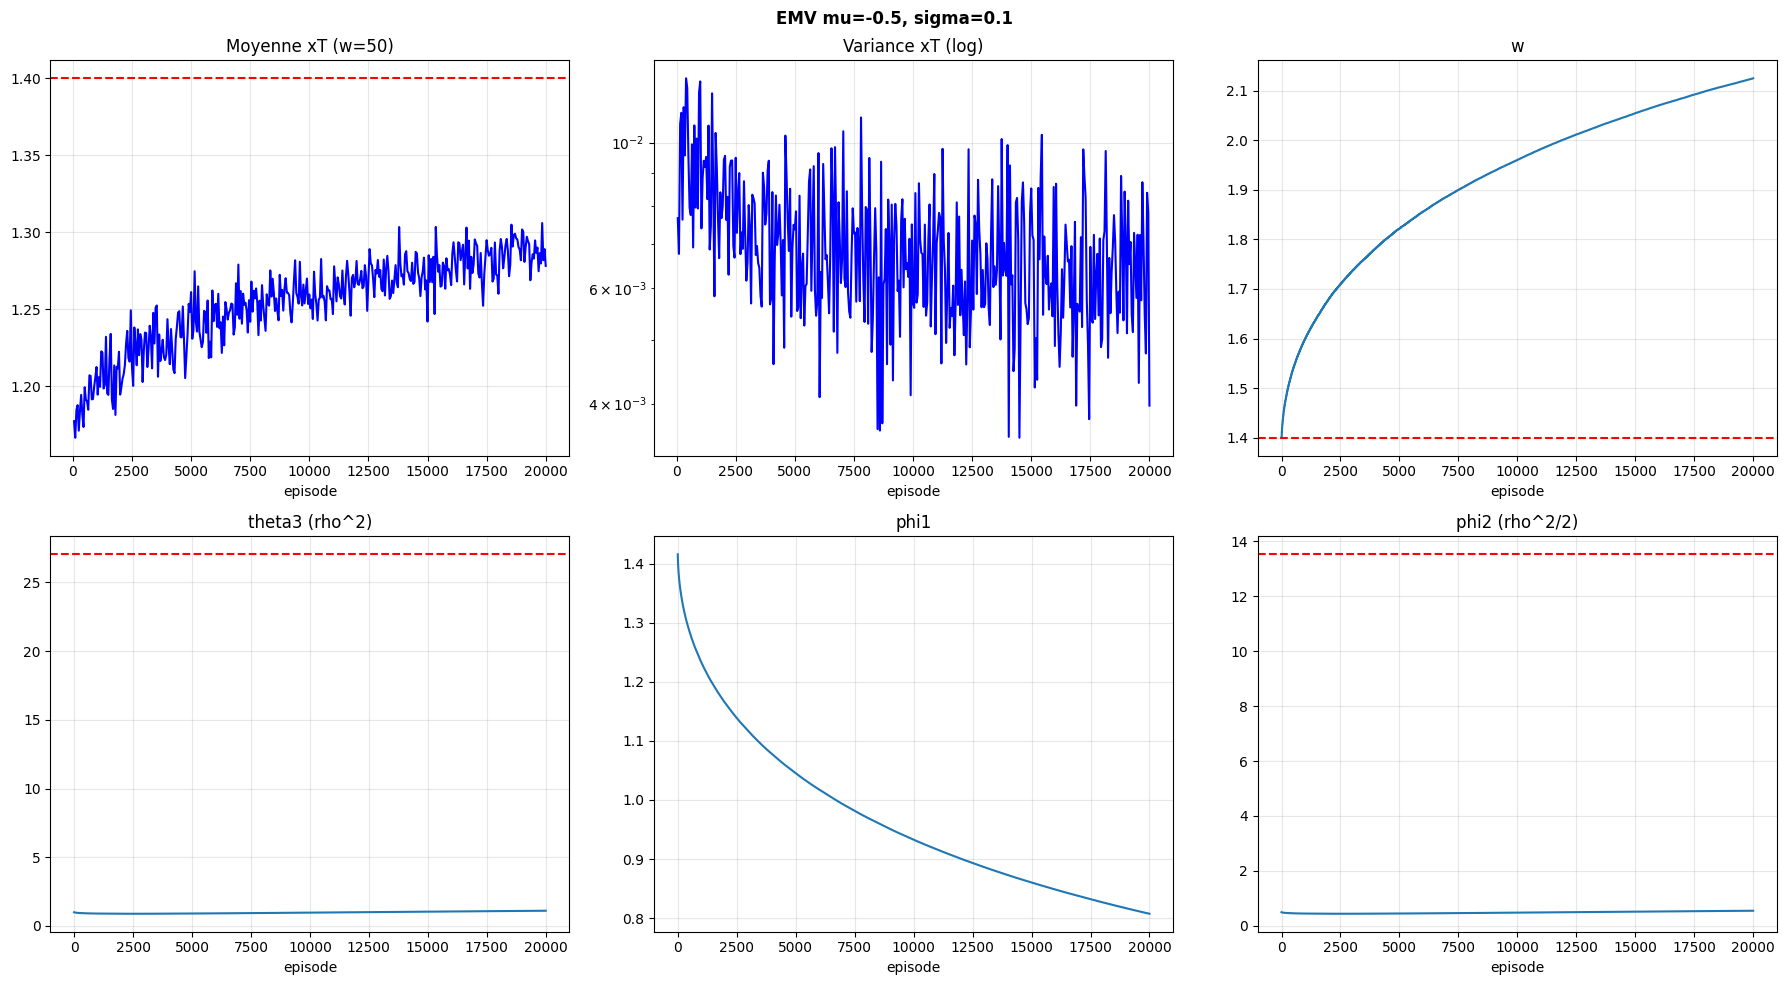

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
xT = emv['xT']; w50=50; nw=len(xT)//w50
means = [xT[i*w50:(i+1)*w50].mean() for i in range(nw)]
varis = [xT[i*w50:(i+1)*w50].var() for i in range(nw)]
ep = np.arange(1,nw+1)*w50

axes[0,0].plot(ep,means,'b-'); axes[0,0].axhline(z,color='r',ls='--')
axes[0,0].set_title('Moyenne xT (w=50)'); axes[0,0].set_xlabel('episode')

axes[0,1].semilogy(ep,np.maximum(varis,1e-8),'b-')
axes[0,1].set_title('Variance xT (log)'); axes[0,1].set_xlabel('episode')

axes[0,2].plot(emv['w']); axes[0,2].axhline(compute_w_star(rho_true),color='r',ls='--')
axes[0,2].set_title('w'); axes[0,2].set_xlabel('episode')

axes[1,0].plot(emv['theta3']); axes[1,0].axhline(rho_true**2,color='r',ls='--')
axes[1,0].set_title('theta3 (rho^2)'); axes[1,0].set_xlabel('episode')

axes[1,1].plot(emv['phi1']); axes[1,1].set_title('phi1'); axes[1,1].set_xlabel('episode')

axes[1,2].plot(emv['phi2']); axes[1,2].axhline(rho_true**2/2,color='r',ls='--')
axes[1,2].set_title('phi2 (rho^2/2)'); axes[1,2].set_xlabel('episode')

plt.suptitle(f'EMV mu={mu_test}, sigma={sigma_test}', fontweight='bold')
plt.tight_layout(); plt.show()

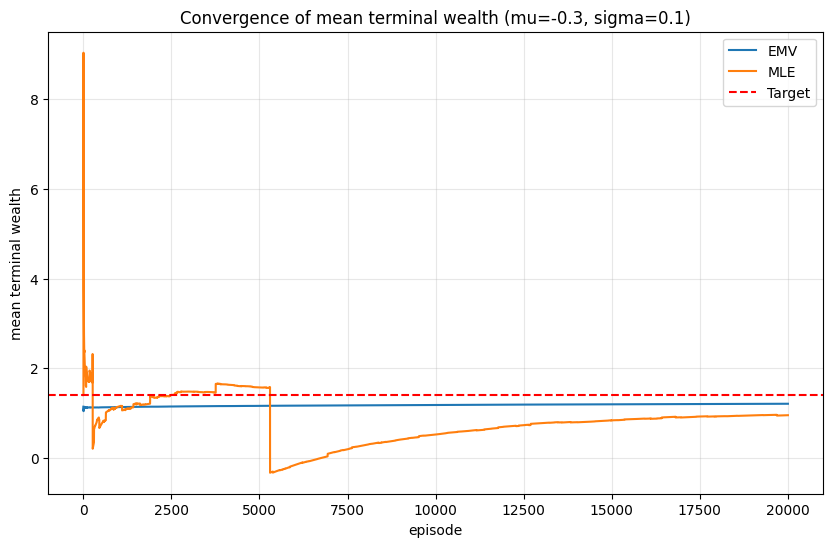

In [68]:
cum_mean_emv = np.cumsum(emv['xT']) / np.arange(1, len(emv['xT']) + 1)
cum_mean_mle = np.cumsum(mle['xT']) / np.arange(1, len(mle['xT']) + 1)
episodes = np.arange(1, len(emv['xT']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(episodes, cum_mean_emv, label='EMV')
plt.plot(episodes, cum_mean_mle, label='MLE')
plt.axhline(z, color='r', linestyle='--', label='Target')
plt.xlabel('episode')
plt.ylabel('mean terminal wealth')
plt.title(f'Convergence of mean terminal wealth (mu={mu_test}, sigma={sigma_test})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:


# Optionnel mais utile si run_emv / run_mle utilisent aussi d'autres générateurs aléatoires
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

def safe_sr(mean_x, var_x):
    return (mean_x - 1.0) / np.sqrt(var_x) if var_x > 1e-12 else 0.0

def run_one_case_like_grid(mu_test=-0.30, sigma_test=0.10, M_emv=5000, eval_last=2000):
    # même seed que dans la grille
    seed = 12345 + int((mu_test + 1) * 1000) + int(sigma_test * 10000)

    # ---- EMV ----
    set_all_seeds(seed)
    emv = run_emv(mu_test, sigma_test, M=M_emv, seed=seed)
    le = np.asarray(emv['xT'][-eval_last:], dtype=float)
    me, ve = le.mean(), le.var()
    sre = safe_sr(me, ve)

    # ---- MLE ----
    set_all_seeds(seed)
    mle = run_mle(mu_test, sigma_test, M=M_emv, seed=seed)
    lm = np.asarray(mle['xT'][-eval_last:], dtype=float)
    mm, vm = lm.mean(), lm.var()
    srm = safe_sr(mm, vm)

    best = "E" if sre > srm else "M"

    print(f"{'Scenario':>20s} | {'--- EMV ---':^26s} | {'--- MLE ---':^26s} | W")
    print(f"{'':>20s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} |")
    print("-" * 82)
    print(f"{'[1/1] mu=' + format(mu_test, '+.0%') + ' s=' + format(sigma_test, '.0%'):>20s} | "
          f"{me:7.3f} {ve:7.4f} {sre:7.3f} | "
          f"{mm:7.3f} {vm:7.4f} {srm:7.3f} | {best}")

    return {
        "mu": mu_test,
        "sigma": sigma_test,
        "seed": seed,
        "EMV_mean": me,
        "EMV_var": ve,
        "EMV_SR": sre,
        "MLE_mean": mm,
        "MLE_var": vm,
        "MLE_SR": srm,
        "winner": best,
        "emv_obj": emv,
        "mle_obj": mle
    }

# ===== Exécution du cas unique exactement comme dans la grille =====
res_single = run_one_case_like_grid(mu_test=-0.30, sigma_test=0.10, M_emv=5000, eval_last=2000)

            Scenario |        --- EMV ---         |        --- MLE ---         | W
                     |    Mean     Var      SR |    Mean     Var      SR |
----------------------------------------------------------------------------------
 [1/1] mu=-30% s=10% |   1.268  0.0078   3.033 |   1.764 140.2750   0.065 | E


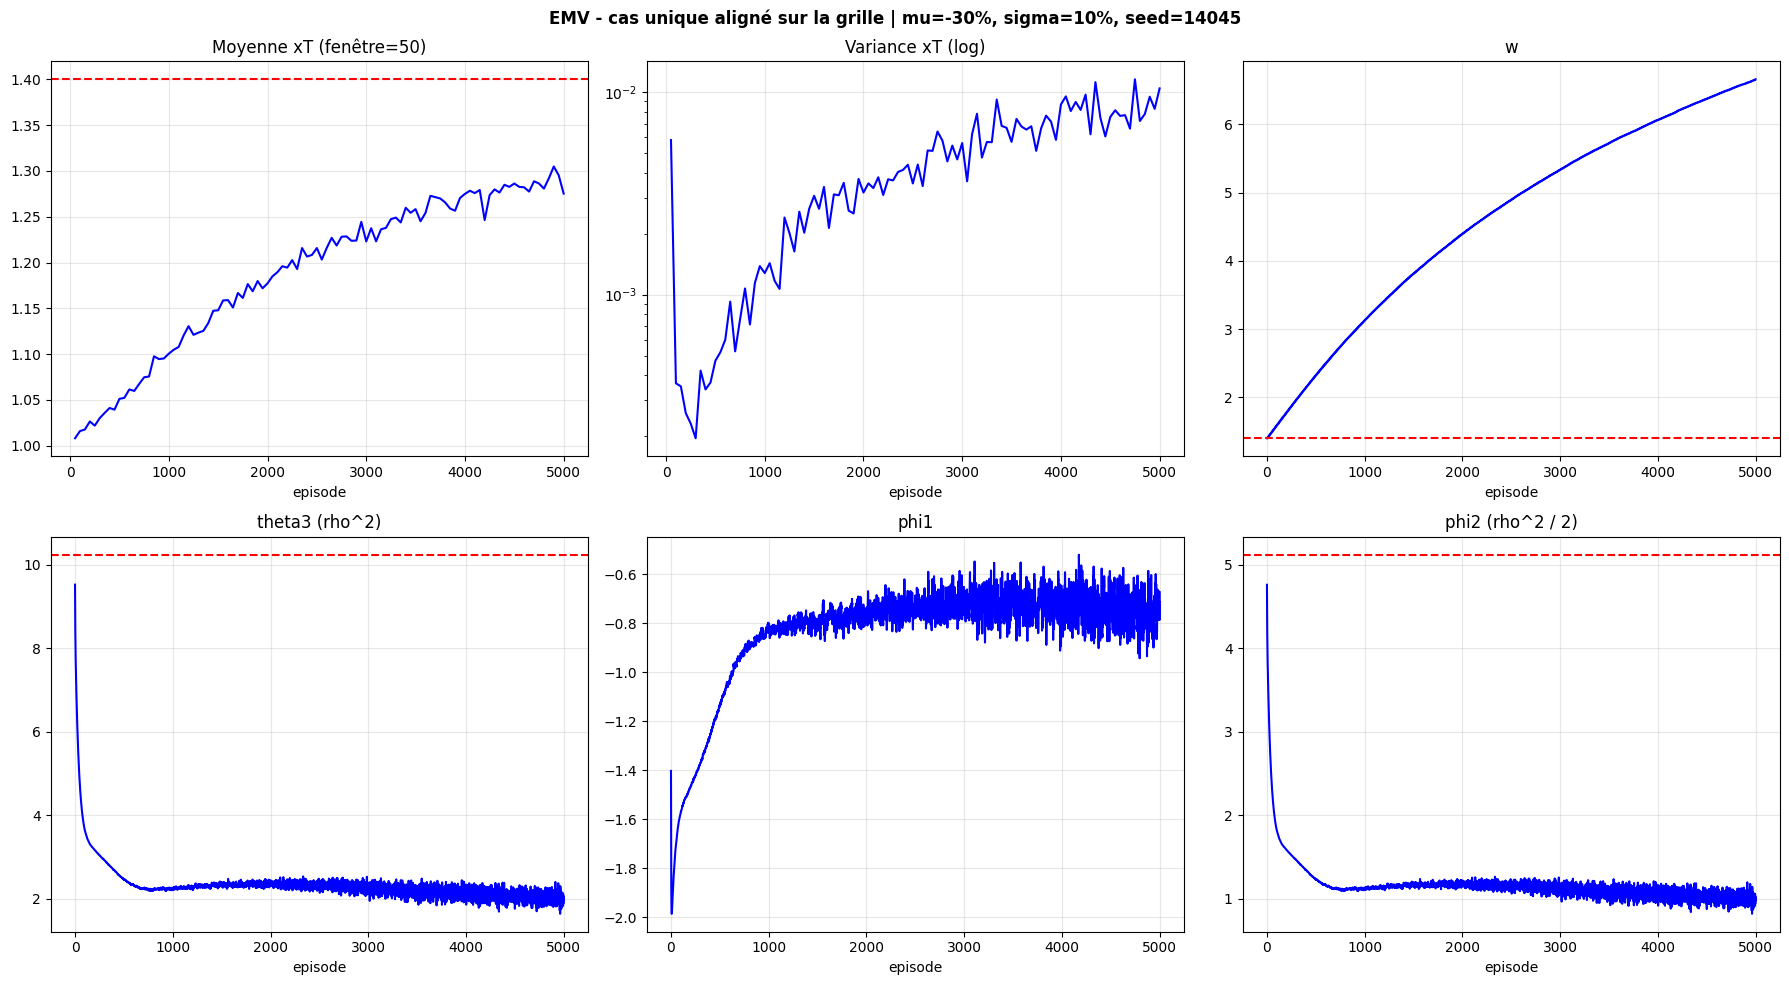

In [ ]:


# ============================================================
# Choix du run à tracer
# - res_single      : même protocole que la grille (M=5000)
# - res_single_20k  : version plus longue si tu l'as calculée
# ============================================================
res_plot = res_single
# res_plot = res_single_20k

emv = res_plot["emv_obj"]
mu_test = res_plot["mu"]
sigma_test = res_plot["sigma"]
seed_used = res_plot["seed"]

# Hypothèses : r_rate et compute_w_star existent déjà dans le notebook
rho_true = (mu_test - r_rate) / sigma_test
w_star = compute_w_star(rho_true)

# On récupère les trajectoires
xT = np.asarray(emv["xT"], dtype=float)
w_path = np.asarray(emv["w"], dtype=float)
theta3_path = np.asarray(emv["theta3"], dtype=float)
phi1_path = np.asarray(emv["phi1"], dtype=float)
phi2_path = np.asarray(emv["phi2"], dtype=float)

# ============================================================
# Statistiques glissantes sur xT
# ============================================================
w50 = 50
nw = len(xT) // w50
xT_trim = xT[:nw * w50]

means = np.array([xT_trim[i*w50:(i+1)*w50].mean() for i in range(nw)])
varis = np.array([xT_trim[i*w50:(i+1)*w50].var() for i in range(nw)])
ep = np.arange(1, nw + 1) * w50

# Cible de richesse terminale : utilise z si déjà défini dans le notebook,
# sinon prend 1.4 par défaut
z_plot = globals().get("z", 1.4)

# ============================================================
# Figures
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1) Moyenne glissante de xT
axes[0, 0].plot(ep, means, 'b-')
axes[0, 0].axhline(z_plot, color='r', ls='--')
axes[0, 0].set_title(f"Moyenne xT (fenêtre={w50})")
axes[0, 0].set_xlabel("episode")

# 2) Variance glissante de xT (log)
axes[0, 1].semilogy(ep, np.maximum(varis, 1e-12), 'b-')
axes[0, 1].set_title("Variance xT (log)")
axes[0, 1].set_xlabel("episode")

# 3) Poids w
axes[0, 2].plot(w_path, 'b-')
axes[0, 2].axhline(w_star, color='r', ls='--')
axes[0, 2].set_title("w")
axes[0, 2].set_xlabel("episode")

# 4) theta3
axes[1, 0].plot(theta3_path, 'b-')
axes[1, 0].axhline(rho_true**2, color='r', ls='--')
axes[1, 0].set_title("theta3 (rho^2)")
axes[1, 0].set_xlabel("episode")

# 5) phi1
axes[1, 1].plot(phi1_path, 'b-')
axes[1, 1].set_title("phi1")
axes[1, 1].set_xlabel("episode")

# 6) phi2
axes[1, 2].plot(phi2_path, 'b-')
axes[1, 2].axhline(rho_true**2 / 2, color='r', ls='--')
axes[1, 2].set_title("phi2 (rho^2 / 2)")
axes[1, 2].set_xlabel("episode")

plt.suptitle(
    f"EMV - cas unique aligné sur la grille | mu={mu_test:+.0%}, sigma={sigma_test:.0%}, seed={seed_used}",
    fontweight="bold"
)
plt.tight_layout()
plt.show()


## 8. Grille complete (Table 1)
> Reduire M_emv pour test rapide. Avec M=20000 compter ~1-2h.

In [ ]:
mu_values = [-0.50, -0.30, -0.10, 0.0, 0.10, 0.30, 0.50]
sigma_values = [0.10, 0.20, 0.30, 0.40]
M_emv = 5000  # reduire a 5000 pour test rapide
eval_last = 2000

results = []
total = len(mu_values) * len(sigma_values)
count = 0

print(f"{'Scenario':>20s} | {'--- EMV ---':^26s} | {'--- MLE ---':^26s} | W")
print(f"{'':>20s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} |")
print("-" * 82)

for sigma in sigma_values:
    for mu in mu_values:
        count += 1
        seed = 12345 + int((mu+1)*1000) + int(sigma*10000)
        
        emv = run_emv(mu, sigma, M=M_emv, seed=seed)
        le = emv['xT'][-eval_last:]
        me,ve = le.mean(), le.var()
        sre = (me-1)/np.sqrt(ve) if ve > 1e-12 else 0
        
        mle = run_mle(mu, sigma, M=M_emv, seed=seed)
        lm = mle['xT'][-eval_last:]
        mm,vm = lm.mean(), lm.var()
        srm = (mm-1)/np.sqrt(vm) if vm > 1e-12 else 0
        
        best = "E" if sre > srm else "M"
        print(f"[{count:2d}/{total}] mu={mu:+.0%} s={sigma:.0%} | {me:7.3f} {ve:7.4f} {sre:7.3f} | {mm:7.3f} {vm:7.4f} {srm:7.3f} | {best}")
        results.append(dict(mu=mu,sigma=sigma,EMV_mean=me,EMV_var=ve,EMV_SR=sre,
                            MLE_mean=mm,MLE_var=vm,MLE_SR=srm))

print("-" * 82)
nw = sum(1 for r in results if r['EMV_SR'] > r['MLE_SR'])
print(f"EMV gagne en SR : {nw}/{total} ({nw/total:.0%})")

            Scenario |        --- EMV ---         |        --- MLE ---         | W
                     |    Mean     Var      SR |    Mean     Var      SR |
----------------------------------------------------------------------------------
[ 1/28] mu=-50% s=10% |   1.332  0.0043   5.032 |   1.390  0.3085   0.702 | E
[ 2/28] mu=-30% s=10% |   1.268  0.0078   3.033 |   1.764 140.2750   0.065 | E
[ 3/28] mu=-10% s=10% |   1.143  0.0142   1.203 |   1.436 1231.2766   0.012 | E
[ 4/28] mu=+0% s=10% |   1.031  0.0234   0.200 |  -0.735 6607.4452  -0.021 | E
[ 5/28] mu=+10% s=10% |   1.102  0.0169   0.785 |   0.890 150481.6049  -0.000 | E
[ 6/28] mu=+30% s=10% |   1.246  0.0083   2.700 |   1.246 386.0212   0.013 | E
[ 7/28] mu=+50% s=10% |   1.318  0.0049   4.531 |   1.408  0.1040   1.265 | E
[ 8/28] mu=-50% s=20% |   1.266  0.0105   2.601 |   1.288 275.2804   0.017 | E
[ 9/28] mu=-30% s=20% |   1.190  0.0149   1.554 |   2.658 6395.3440   0.021 | E
[10/28] mu=-10% s=20% |   1.089  0.0222   0.5

## 9. Visualisations

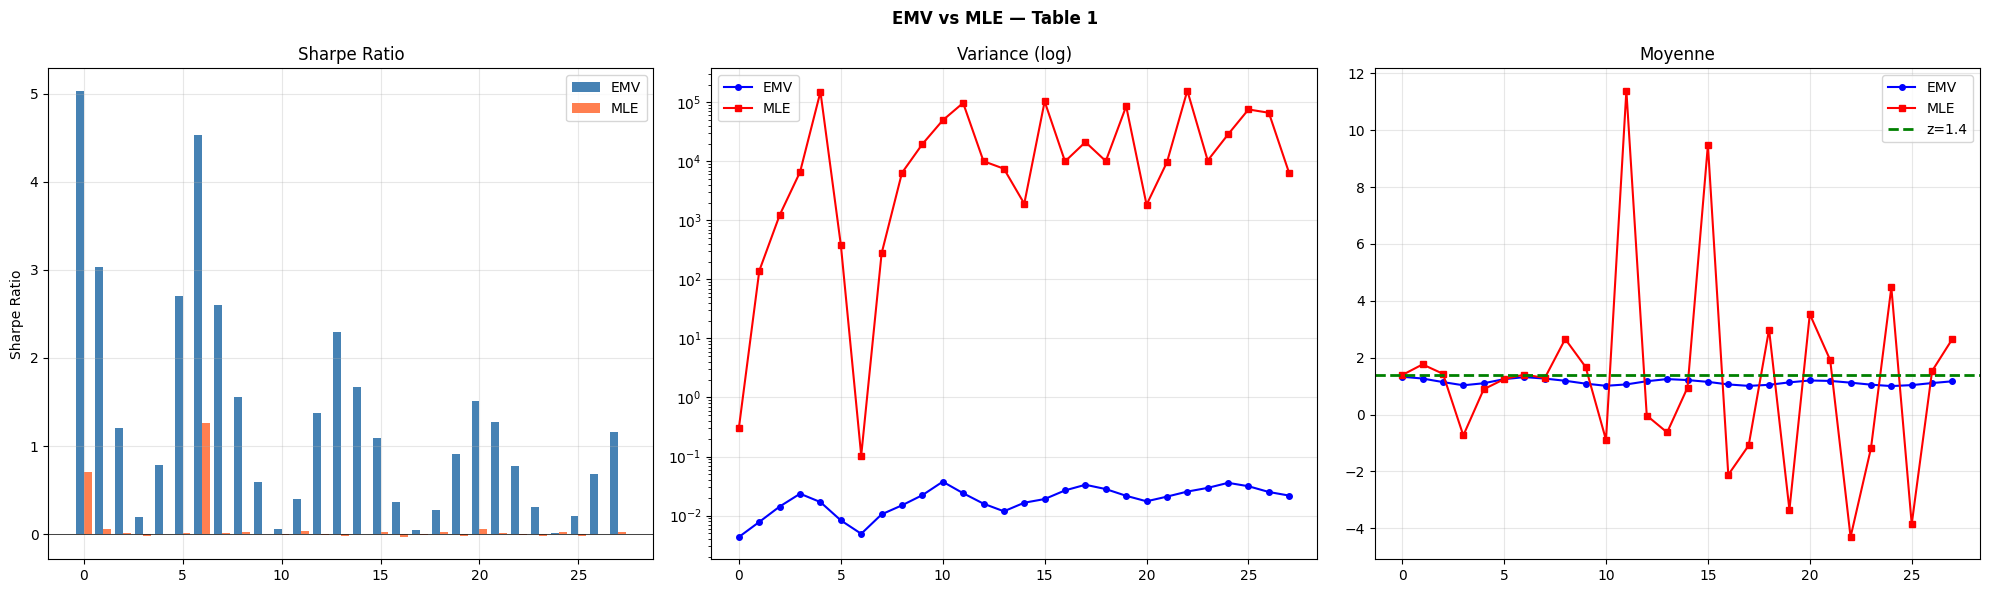

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
xp = np.arange(len(results))

ax = axes[0]
ax.bar(xp-0.2, [r['EMV_SR'] for r in results], 0.4, label='EMV', color='steelblue')
ax.bar(xp+0.2, [r['MLE_SR'] for r in results], 0.4, label='MLE', color='coral')
ax.set_ylabel('Sharpe Ratio'); ax.set_title('Sharpe Ratio'); ax.legend()
ax.axhline(0,color='k',lw=0.5)

ax = axes[1]
ax.semilogy([r['EMV_var'] for r in results], 'bo-', ms=4, label='EMV')
ax.semilogy([r['MLE_var'] for r in results], 'rs-', ms=4, label='MLE')
ax.set_title('Variance (log)'); ax.legend()

ax = axes[2]
ax.plot([r['EMV_mean'] for r in results], 'bo-', ms=4, label='EMV')
ax.plot([r['MLE_mean'] for r in results], 'rs-', ms=4, label='MLE')
ax.axhline(z,color='g',ls='--',lw=2, label=f'z={z}')
ax.set_title('Moyenne'); ax.legend()

plt.suptitle('EMV vs MLE — Table 1', fontweight='bold')
plt.tight_layout(); plt.show()

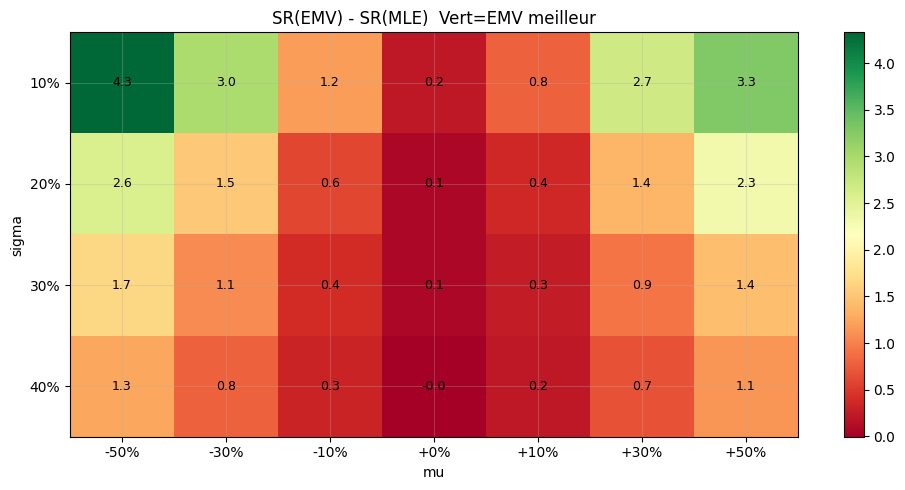

In [ ]:
# Heatmap
sr_diff = np.zeros((len(sigma_values), len(mu_values)))
for r in results:
    i = sigma_values.index(r['sigma'])
    j = mu_values.index(r['mu'])
    sr_diff[i,j] = r['EMV_SR'] - r['MLE_SR']

fig, ax = plt.subplots(figsize=(10,5))
im = ax.imshow(sr_diff, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(mu_values))); ax.set_xticklabels([f'{m:+.0%}' for m in mu_values])
ax.set_yticks(range(len(sigma_values))); ax.set_yticklabels([f'{s:.0%}' for s in sigma_values])
ax.set_xlabel('mu'); ax.set_ylabel('sigma')
ax.set_title('SR(EMV) - SR(MLE)  Vert=EMV meilleur')
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        ax.text(j,i,f'{sr_diff[i,j]:.1f}',ha='center',va='center',fontsize=9)
plt.colorbar(im); plt.tight_layout(); plt.show()

# EMV vs MLE — Wang & Zhou (2019) — changement de maturité: passage de 1 an à 6 mois et 2 ans 

In [ ]:

def target_from_annualized_return(T, annual_return=0.40, x0=1.0):
    """Cible terminale correspondant a un objectif annualise constant."""
    return x0 * (1.0 + annual_return) ** T

def terminal_stats(xT, eval_last=2000, x0=1.0, sr_mode='paper'):
    """Resume les dernieres richesses terminales.

    sr_mode='paper'   -> SR = mean / sqrt(var)
    sr_mode='excess'  -> SR = (mean - x0) / sqrt(var)
    """
    tail = np.asarray(xT[-eval_last:], dtype=float)
    mean_ = float(np.mean(tail))
    var_ = float(np.var(tail))
    if var_ <= 1e-12:
        sr_ = 0.0
    else:
        if sr_mode == 'paper':
            sr_ = float(mean_ / np.sqrt(var_))
        elif sr_mode == 'excess':
            sr_ = float((mean_ - x0) / np.sqrt(var_))
        else:
            raise ValueError("sr_mode doit etre 'paper' ou 'excess'")
    return {'mean': mean_, 'var': var_, 'sr': sr_, 'tail': tail}

def compare_single_scenario_by_maturity(mu, sigma, T_values=(0.5, 1.0, 2.0),
                                        x0=1.0, r=0.02, dt=1/252,
                                        target_mode='annualized',
                                        z_fixed=1.4,
                                        annual_return=0.40,
                                        M=5000, eval_last=2000, seed0=2026):
    """Compare EMV et MLE pour plusieurs maturites sur un scenario (mu, sigma)."""
    rows = []
    for idx, T_ in enumerate(T_values):
        if target_mode == 'annualized':
            z_ = target_from_annualized_return(T_, annual_return=annual_return, x0=x0)
        elif target_mode == 'fixed':
            z_ = z_fixed
        else:
            raise ValueError("target_mode doit etre 'annualized' ou 'fixed'")

        seed = seed0 + idx * 1000 + int((mu + 1.0) * 1000) + int(sigma * 10000) + int(T_ * 100)
        emv_res = run_emv(mu, sigma, r=r, x0=x0, z=z_, T=T_, dt=dt, M=M, seed=seed)
        mle_res = run_mle(mu, sigma, r=r, x0=x0, z=z_, T=T_, dt=dt, M=M, seed=seed)

        emv_stats = terminal_stats(emv_res['xT'], eval_last=eval_last, x0=x0, sr_mode='paper')
        mle_stats = terminal_stats(mle_res['xT'], eval_last=eval_last, x0=x0, sr_mode='paper')

        rows.append({
            'T': T_,
            'n_steps': int(round(T_ / dt)),
            'z': z_,
            'EMV_mean': emv_stats['mean'],
            'EMV_var': emv_stats['var'],
            'EMV_SR': emv_stats['sr'],
            'MLE_mean': mle_stats['mean'],
            'MLE_var': mle_stats['var'],
            'MLE_SR': mle_stats['sr'],
            'EMV_xT': emv_res['xT'],
            'MLE_xT': mle_res['xT'],
            'EMV_w': emv_res['w'],
            'EMV_theta3': emv_res['theta3'],
        })
    return rows

print("Fonctions maturite definies.")

Fonctions maturite definies.



## 9. Test de maturite sur un scenario central

On utilise ici un scenario central du papier :
- \(\mu=-50\%\)
- \(\sigma=10\%\)

On commence par la convention la plus naturelle :
**meme objectif annualise de +40%**, donc \(z(T)=1.4^T\).
Pour accelerer le test, on prend ici `M=5000`.

In [ ]:
mu_mat, sigma_mat = -0.50, 0.10
T_values = [0.25,0.5, 1.0, 2.0, 3.0]

maturity_rows_ann = compare_single_scenario_by_maturity(
    mu=mu_mat,
    sigma=sigma_mat,
    T_values=T_values,
    x0=x0,
    r=r_rate,
    dt=dt,
    target_mode='annualized',
    annual_return=0.40,
    M=5000,
    eval_last=2000,
    seed0=4242
)

print(f"{'T':>6s} {'pas':>6s} {'z(T)':>8s} | {'EMV mean':>9s} {'EMV var':>10s} {'EMV SR':>8s} | {'MLE mean':>9s} {'MLE var':>10s} {'MLE SR':>8s}")
print("-"*90)
for row in maturity_rows_ann:
    print(f"{row['T']:6.2f} {row['n_steps']:6d} {row['z']:8.4f} | "
          f"{row['EMV_mean']:9.4f} {row['EMV_var']:10.4f} {row['EMV_SR']:8.4f} | "
          f"{row['MLE_mean']:9.4f} {row['MLE_var']:10.4f} {row['MLE_SR']:8.4f}")


     T    pas     z(T) |  EMV mean    EMV var   EMV SR |  MLE mean    MLE var   MLE SR
------------------------------------------------------------------------------------------
  0.25     63   1.0878 |    1.0790     0.0013  30.1320 |    1.0894     0.0074  12.6711
  0.50    126   1.1832 |    1.1602     0.0021  25.5711 |    1.1863     0.0070  14.2130
  1.00    252   1.4000 |    1.3284     0.0044  19.9611 |    1.4036     0.0147  11.5709
  2.00    504   1.9600 | -601325.2201 35239900475955152.0000  -0.0032 |    1.9619     0.0055  26.3724
  3.00    756   2.7440 | 2240810.6706 2981380908326362.5000   0.0410 |    2.7534     0.1368   7.4433


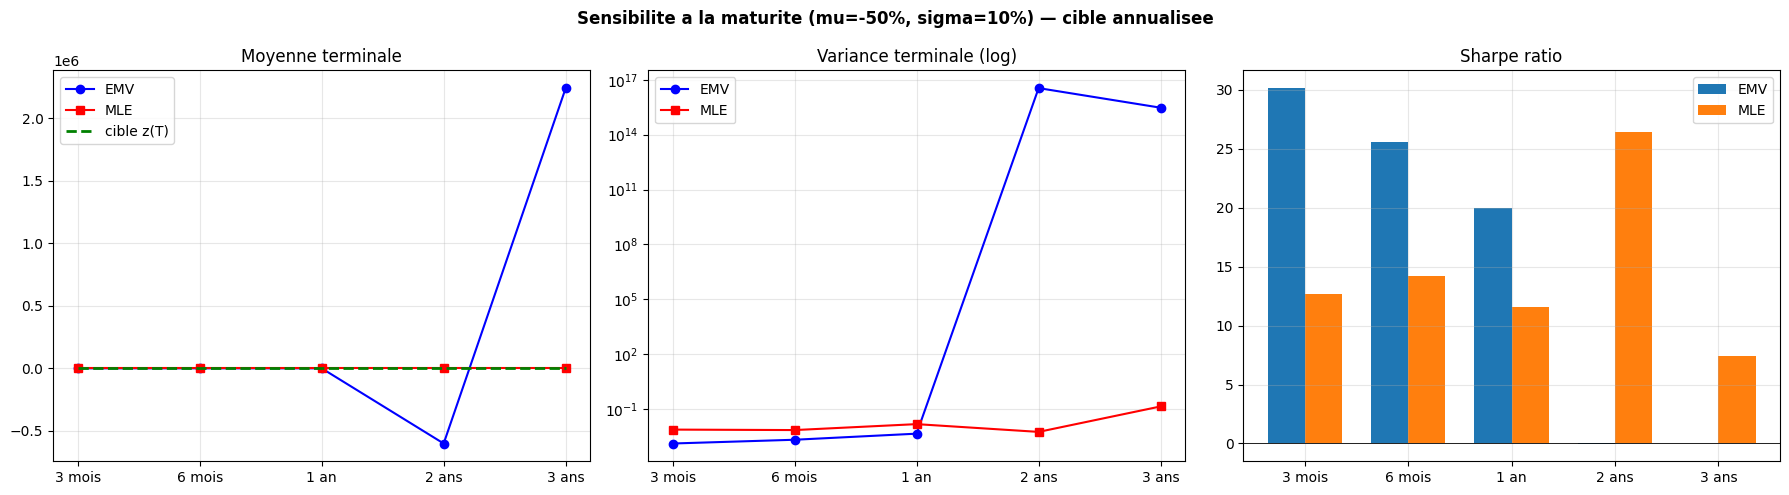

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['3 mois', '6 mois', '1 an', '2 ans', '3 ans']
xp = np.arange(len(maturity_rows_ann))

axes[0].plot(xp, [r['EMV_mean'] for r in maturity_rows_ann], 'bo-', label='EMV')
axes[0].plot(xp, [r['MLE_mean'] for r in maturity_rows_ann], 'rs-', label='MLE')
axes[0].plot(xp, [r['z'] for r in maturity_rows_ann], 'g--', lw=2, label='cible z(T)')
axes[0].set_xticks(xp); axes[0].set_xticklabels(labels)
axes[0].set_title('Moyenne terminale'); axes[0].legend()

axes[1].semilogy(xp, [max(r['EMV_var'],1e-12) for r in maturity_rows_ann], 'bo-', label='EMV')
axes[1].semilogy(xp, [max(r['MLE_var'],1e-12) for r in maturity_rows_ann], 'rs-', label='MLE')
axes[1].set_xticks(xp); axes[1].set_xticklabels(labels)
axes[1].set_title('Variance terminale (log)'); axes[1].legend()

axes[2].bar(xp-0.18, [r['EMV_SR'] for r in maturity_rows_ann], width=0.36, label='EMV')
axes[2].bar(xp+0.18, [r['MLE_SR'] for r in maturity_rows_ann], width=0.36, label='MLE')
axes[2].axhline(0, color='k', lw=0.6)
axes[2].set_xticks(xp); axes[2].set_xticklabels(labels)
axes[2].set_title('Sharpe ratio')
axes[2].legend()

plt.suptitle(f'Sensibilite a la maturite (mu={mu_mat:+.0%}, sigma={sigma_mat:.0%}) — cible annualisee', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

maturity_rows_fixed = compare_single_scenario_by_maturity(
    mu=mu_mat,
    sigma=sigma_mat,
    T_values=T_values,
    x0=x0,
    r=r_rate,
    dt=dt,
    target_mode='fixed',
    z_fixed=1.4,
    M=5000,
    eval_last=2000,
    seed0=4242
)

print(f"{'T':>6s} {'pas':>6s} {'z':>8s} | {'EMV mean':>9s} {'EMV var':>10s} {'EMV SR':>8s} | {'MLE mean':>9s} {'MLE var':>10s} {'MLE SR':>8s}")
print("-"*90)
for row in maturity_rows_fixed:
    print(f"{row['T']:6.2f} {row['n_steps']:6d} {row['z']:8.4f} | "
          f"{row['EMV_mean']:9.4f} {row['EMV_var']:10.4f} {row['EMV_SR']:8.4f} | "
          f"{row['MLE_mean']:9.4f} {row['MLE_var']:10.4f} {row['MLE_SR']:8.4f}")

     T    pas        z |  EMV mean    EMV var   EMV SR |  MLE mean    MLE var   MLE SR
------------------------------------------------------------------------------------------
  0.25     63   1.4000 |    1.3914     0.0210   9.6129 |    1.4076     0.1536   3.5918
  0.50    126   1.4000 |    1.3567     0.0088  14.4356 |    1.4066     0.0332   7.7195
  1.00    252   1.4000 |    1.3284     0.0044  19.9611 |    1.4036     0.0147  11.5709
  2.00    504   1.4000 | -601325.2300 35239900475868856.0000  -0.0032 |    1.4008     0.0010  45.1913
  3.00    756   1.4000 | 2240810.6706 2981380908326362.5000   0.0410 |    1.4021     0.0072  16.5266


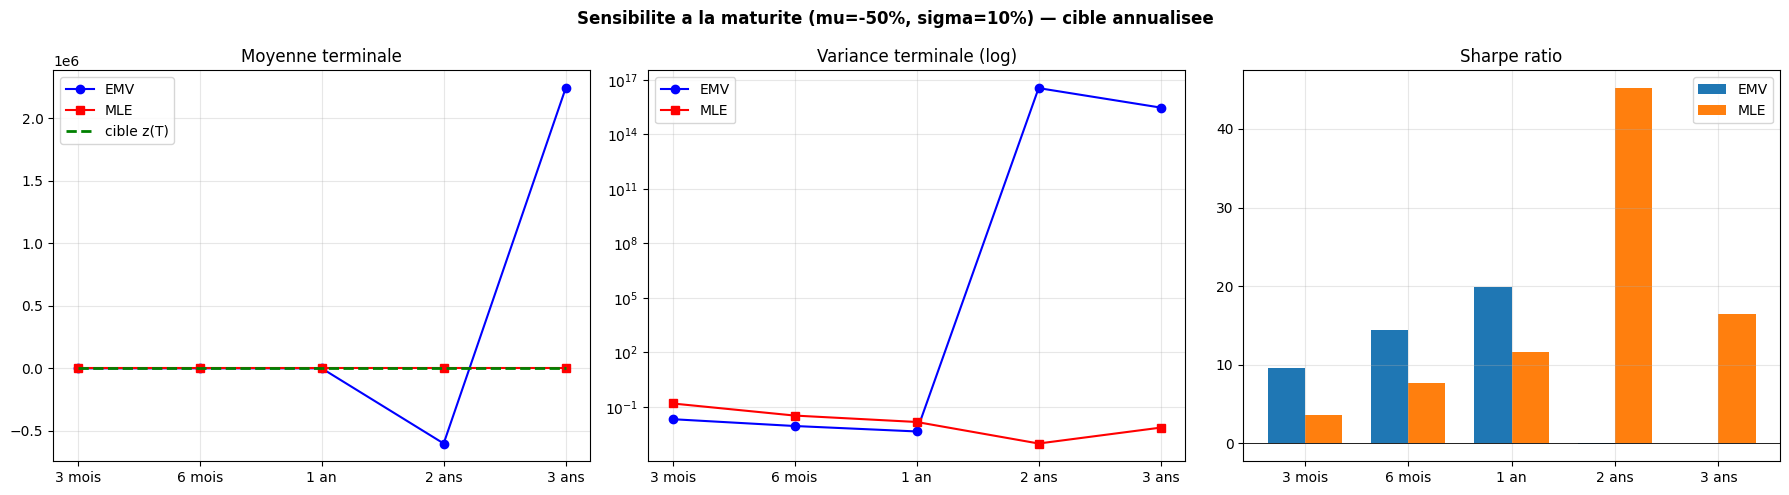

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['3 mois', '6 mois', '1 an', '2 ans', '3 ans']
xp = np.arange(len(maturity_rows_fixed))

axes[0].plot(xp, [r['EMV_mean'] for r in maturity_rows_fixed], 'bo-', label='EMV')
axes[0].plot(xp, [r['MLE_mean'] for r in maturity_rows_fixed], 'rs-', label='MLE')
axes[0].plot(xp, [r['z'] for r in maturity_rows_fixed], 'g--', lw=2, label='cible z(T)')
axes[0].set_xticks(xp); axes[0].set_xticklabels(labels)
axes[0].set_title('Moyenne terminale'); axes[0].legend()

axes[1].semilogy(xp, [max(r['EMV_var'],1e-12) for r in maturity_rows_fixed], 'bo-', label='EMV')
axes[1].semilogy(xp, [max(r['MLE_var'],1e-12) for r in maturity_rows_fixed], 'rs-', label='MLE')
axes[1].set_xticks(xp); axes[1].set_xticklabels(labels)
axes[1].set_title('Variance terminale (log)'); axes[1].legend()

axes[2].bar(xp-0.18, [r['EMV_SR'] for r in maturity_rows_fixed], width=0.36, label='EMV')
axes[2].bar(xp+0.18, [r['MLE_SR'] for r in maturity_rows_fixed], width=0.36, label='MLE')
axes[2].axhline(0, color='k', lw=0.6)
axes[2].set_xticks(xp); axes[2].set_xticklabels(labels)
axes[2].set_title('Sharpe ratio')
axes[2].legend()

plt.suptitle(f'Sensibilite a la maturite (mu={mu_mat:+.0%}, sigma={sigma_mat:.0%}) — cible annualisee', fontweight='bold')
plt.tight_layout()
plt.show()